# L10 · NB 02 — Attention, by hand

> ⏱️ **~35 min** core (Sections 1–8) · +15 min for the 🟡 Extension · no model downloads — pure CPU math

> *We've used transformers as black boxes for two lessons. Time to open one up. The single mechanism that makes everything work is **attention** — and it's just one matrix multiplication plus a softmax.*

By the end of this notebook you will:

1. Have computed attention scores by hand on a small example
2. Understand what queries, keys, and values are *for*
3. Have seen multi-head attention work, with each head specialising on a different relationship
4. Be ready to USE pretrained transformers in NB 03 without it feeling like magic

---

### Where you are in L10

Marcus asked for a shopping assistant. Sarah can't build it in one leap — she works through four notebooks, each answering the next question in the chain:

| Step | Notebook | Sarah's question |
|---|---|---|
| 1 | `01_monday_morning` | What can pretrained transformers already do, out of the box? |
| 2 | `02_attention_intuition` 👈 **you are here** | *Why* do they work? What is this "attention" everyone talks about? |
| 3 | `03_using_an_llm` | How do I drive a generative LLM myself — tokens, sampling, chat? |
| 4 | `04_rag_pipeline` | How do I ground it in NorthStar's catalogue? → the shopping assistant |

Right now you're on **step 2 of 4**. Each notebook stands on the one before it — run them in order.


## 1 · Setup + the toy example


> **Why this cell first.**
> No big models here — this notebook is pure intuition, built on a tiny hand-made example. The setup just imports our tools and **fixes the random seeds** (`torch.manual_seed(0)`, `np.random.seed(0)`). That matters: a lot of the attention below starts from *random* weights, and pinning the seed means the numbers you see match the numbers in the walkthrough — your run and Sarah's run line up exactly. the fixed random seed keeps runs stable on any laptop.


In [12]:
# Core scientific/ML stack: numpy for arrays, torch for tensors + the attention math,
# torch.nn / functional for layers (LayerNorm, softmax), matplotlib + seaborn for heatmaps.
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# (Removed the old one-CPU-thread cap — it made CPU-only machines much slower.)
torch.manual_seed(0)      # fix torch's RNG so the random Q/K/V weights below are identical every run
np.random.seed(0)         # fix numpy's RNG too, for any numpy randomness

# Toy: 6-token sentence
# Each token is represented by a 4-dimensional embedding (in real models, 768+)
# We hand-craft embeddings so that 'it' has features mid-way between 'trophy' and 'suitcase' — ambiguous.
TOKENS = ['the', 'trophy', "didn't", 'fit', 'because', 'it']
D = 4  # embedding dimension (the "width" of each token vector)

# Hand-crafted embeddings — each row is one token's embedding (shape: 6 tokens x 4 dims)
X = torch.tensor([
    [0.1, 0.0, 0.0, 0.0],   # the         (function word, low signal)
    [0.0, 1.0, 0.0, 0.0],   # trophy      (entity dim = 1)
    [0.0, 0.0, 0.1, 0.0],   # didn't      (function word)
    [0.0, 0.0, 0.0, 1.0],   # fit         (verb dim = 1)
    [0.1, 0.0, 0.0, 0.0],   # because     (function word)
    [0.0, 0.5, 0.0, 0.5],   # it          (ambiguous — half-entity, half-verb)
])
print(f"Sequence: {TOKENS}")
# X.shape is (seq_len, D) = (6, 4): one 4-dim row vector per token
print(f"Embeddings shape: {X.shape}  ({len(TOKENS)} tokens × {D} dims)")

Sequence: ['the', 'trophy', "didn't", 'fit', 'because', 'it']
Embeddings shape: torch.Size([6, 4])  (6 tokens × 4 dims)


## 2 · Self-attention from scratch

Attention's recipe is in 4 steps:

1. Project each token to a **query** (Q), **key** (K), and **value** (V) vector
2. Compute similarity scores between every query and every key (dot product)
3. Scale by √d and apply softmax → these are the attention weights
4. Each output token = weighted sum of values, using the attention weights

We'll do this manually.

In [13]:
# Initialise random Q/K/V projection matrices, each (D, D) = (4, 4).
# These are the only learnable params of attention; here they're random (untrained).
# The *0.5 just keeps the random values small so scores don't explode.
W_q = torch.randn(D, D) * 0.5  # turns an embedding into a "query"  (what am I looking for?)
W_k = torch.randn(D, D) * 0.5  # turns an embedding into a "key"    (what do I offer?)
W_v = torch.randn(D, D) * 0.5  # turns an embedding into a "value"  (what info do I pass on?)

# Step 1: project to Q, K, V.
# X is (6, 4) and each W is (4, 4), so X @ W is (6, 4): every token gets its own Q, K, V vector.
Q = X @ W_q
K = X @ W_k
V = X @ W_v
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")

Q shape: torch.Size([6, 4])
K shape: torch.Size([6, 4])
V shape: torch.Size([6, 4])


In [14]:
# Step 2: similarity scores via dot products between every query and every key.
# Q is (6, 4), K.T is (4, 6), so Q @ K.T is (6, 6): scores[i, j] = how much token i's
# query matches token j's key. Higher dot product = more relevant.
scores = Q @ K.T
print(f"Raw scores (Q · Kᵀ):  shape {scores.shape}")
print(scores.numpy())

Raw scores (Q · Kᵀ):  shape torch.Size([6, 6])
[[ 7.4772956e-03  9.9847447e-03 -5.1511789e-04 -8.1582524e-02
   7.4772956e-03 -3.5798889e-02]
 [-1.0447812e-01 -1.0948849e+00 -2.5444077e-03  9.4061172e-01
  -1.0447813e-01 -7.7136591e-02]
 [ 5.3735692e-03  6.5227501e-02  2.4432398e-03 -3.7127260e-02
   5.3735692e-03  1.4050125e-02]
 [-4.5612037e-02 -6.7308509e-01 -2.1843929e-02  8.4881747e-01
  -4.5612037e-02  8.7866195e-02]
 [ 7.4772956e-03  9.9847447e-03 -5.1511789e-04 -8.1582524e-02
   7.4772956e-03 -3.5798889e-02]
 [-7.5045079e-02 -8.8398498e-01 -1.2194168e-02  8.9471459e-01
  -7.5045079e-02  5.3647975e-03]]


In [15]:
# Step 3: scale by sqrt(d), then softmax across each row.
# Dividing by sqrt(D) keeps the scores from growing with dimension, which would push
# softmax into tiny gradients. softmax(dim=-1) turns each ROW into positive numbers that
# sum to 1 -> a probability distribution over "which tokens to attend to".
attn_weights = F.softmax(scores / (D ** 0.5), dim=-1)
print(f"Attention weights (each row sums to 1):")
print(attn_weights.numpy().round(3))

Attention weights (each row sums to 1):
[[0.169 0.169 0.168 0.161 0.169 0.165]
 [0.157 0.096 0.165 0.265 0.157 0.159]
 [0.166 0.171 0.166 0.163 0.166 0.167]
 [0.157 0.115 0.159 0.245 0.157 0.168]
 [0.169 0.169 0.168 0.161 0.169 0.165]
 [0.157 0.105 0.162 0.255 0.157 0.164]]


In [16]:
# Step 4: each output token = weighted sum of all value vectors, using the attention weights.
# attn_weights is (6, 6), V is (6, 4), so the product is (6, 4): output row i blends every
# token's V together, weighted by how much token i attends to each. Same shape as input X.
output = attn_weights @ V
print(f"Output shape: {output.shape}  (same as input — one new vector per token)")
print(output.numpy().round(3))

Output shape: torch.Size([6, 4])  (same as input — one new vector per token)
[[ 0.108  0.302 -0.109 -0.133]
 [ 0.118  0.414 -0.207 -0.23 ]
 [ 0.109  0.305 -0.11  -0.135]
 [ 0.119  0.397 -0.188 -0.213]
 [ 0.108  0.302 -0.109 -0.133]
 [ 0.119  0.405 -0.198 -0.222]]


**That's the whole operation.** Four matrix ops. Every other token's V is averaged in, weighted by how relevant it is to this token's query.

## 3 · Visualise the attention pattern

Each row of `attn_weights` shows what one token is paying attention to. The diagonal is self-attention; off-diagonal is cross-token attention.

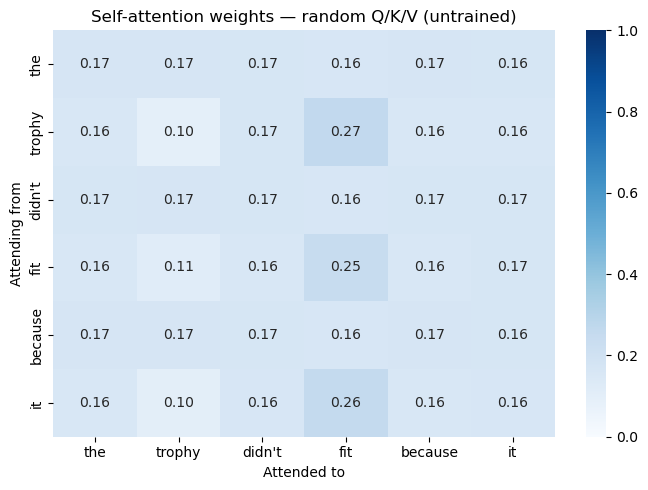

In [17]:
# Visualise attn_weights (6x6) as a heatmap. Row = token attending FROM, column = attended TO.
# Brighter cell = more attention. With random weights the pattern is near-uniform / meaningless.
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(attn_weights.numpy(), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Attended to')
ax.set_ylabel('Attending from')
ax.set_title('Self-attention weights — random Q/K/V (untrained)')
plt.tight_layout()
plt.show()

With **random** weights the attention pattern is random — there's no learned structure yet. In a trained transformer, you'd see something different: 'it' would attend strongly to 'trophy' (or 'suitcase', depending on context), 'fit' would attend to its subject, and so on.

That's the trained pattern attention is supposed to learn. We're seeing the architecture; training data does the rest.

## 4 · Let's simulate a "trained" attention pattern by hand

To make the lesson visceral, let's hand-design weights that make 'it' attend strongly to 'trophy'. This is what a trained model effectively does for this kind of sentence.

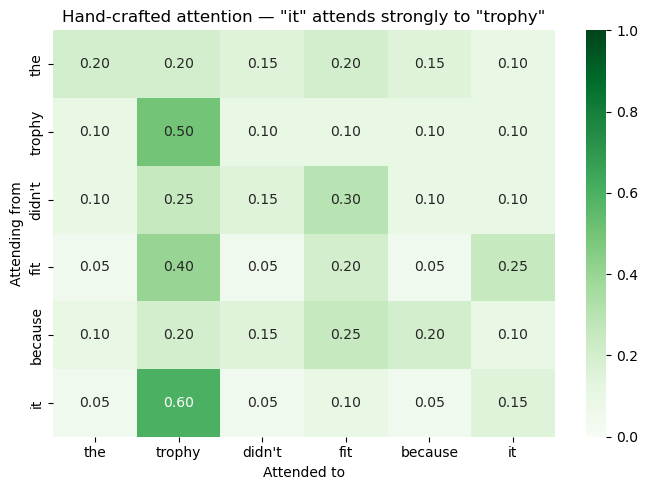

In [18]:
# Override the random matrices with something hand-crafted
# Idea: make Q for 'it' (last token) align with K for 'trophy' (token 1)

# We'll just construct attention weights directly to bypass the projections.
# Each row is a hand-picked distribution that sums to ~1 (what a trained head might learn).
# This is for visualisation — real models learn these weights via gradient descent
hand_attn = torch.tensor([
    # the    trophy didn't  fit    because it     <-- attending TO
    [0.20,   0.20,  0.15,   0.20,  0.15,   0.10],   # the
    [0.10,   0.50,  0.10,   0.10,  0.10,   0.10],   # trophy attends mostly to itself
    [0.10,   0.25,  0.15,   0.30,  0.10,   0.10],   # didn't attends to negated verb
    [0.05,   0.40,  0.05,   0.20,  0.05,   0.25],   # fit attends to its subject and object
    [0.10,   0.20,  0.15,   0.25,  0.20,   0.10],   # because attends broadly
    [0.05,   0.60,  0.05,   0.10,  0.05,   0.15],   # it attends strongly to trophy!
])

# Same heatmap as before, but now the bottom row ('it') puts 0.60 mass on 'trophy'.
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(hand_attn.numpy(), annot=True, fmt='.2f', cmap='Greens',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Attended to')
ax.set_ylabel('Attending from')
ax.set_title('Hand-crafted attention — "it" attends strongly to "trophy"')
plt.tight_layout()
plt.show()

Look at the bottom row. The token **'it'** has 0.60 of its attention mass on **'trophy'**. That's how the model decides 'it' refers to the trophy — by literally focusing on that token when computing its representation.

This is the same sentence pattern you just worked through above: *'The trophy didn't fit because it was too big'* (it = trophy) vs *'... because it was too small'* (it = suitcase) — attention is what lets the model assign different vectors to 'it' in the two cases.

## 5 · Multi-head attention

A single attention layer captures ONE relationship pattern. Real transformers run several attentions in parallel — each "head" learns a different pattern (subject-verb, modifier-noun, coreference, etc.).

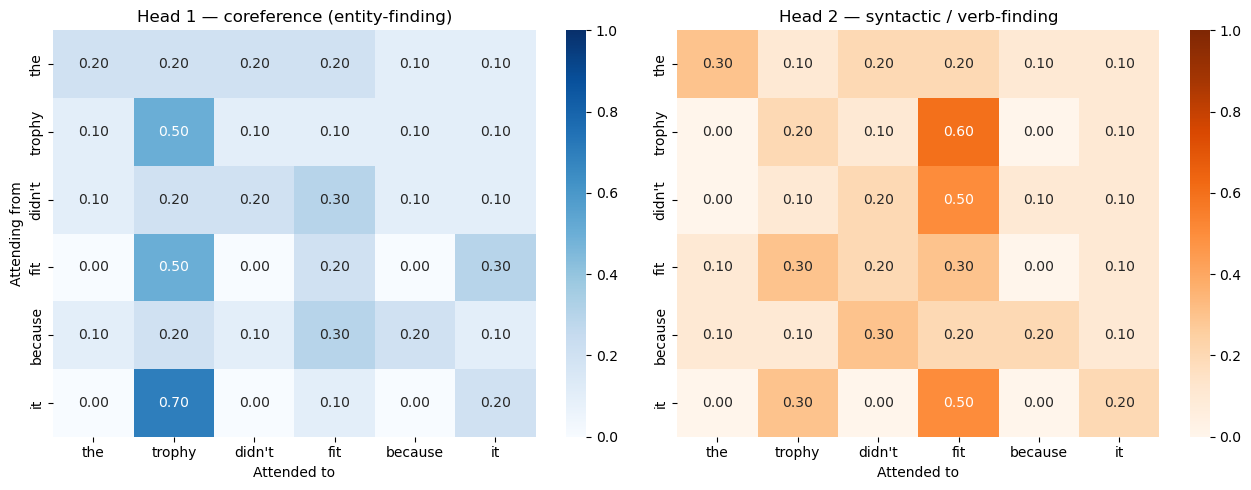

In [19]:
# Demonstrate two attention heads with different focus patterns.
# Each head is its own (6x6) attention matrix — same sentence, different relationship learned.
head_1 = torch.tensor([
    # 'it' focuses on entities
    [0.2, 0.2, 0.2, 0.2, 0.1, 0.1],
    [0.1, 0.5, 0.1, 0.1, 0.1, 0.1],
    [0.1, 0.2, 0.2, 0.3, 0.1, 0.1],
    [0.0, 0.5, 0.0, 0.2, 0.0, 0.3],
    [0.1, 0.2, 0.1, 0.3, 0.2, 0.1],
    [0.0, 0.7, 0.0, 0.1, 0.0, 0.2],   # 'it' -> 'trophy' (coreference head)
])
head_2 = torch.tensor([
    # focuses on syntax / verb structure
    [0.3, 0.1, 0.2, 0.2, 0.1, 0.1],
    [0.0, 0.2, 0.1, 0.6, 0.0, 0.1],   # 'trophy' attends to verb 'fit'
    [0.0, 0.1, 0.2, 0.5, 0.1, 0.1],
    [0.1, 0.3, 0.2, 0.3, 0.0, 0.1],
    [0.1, 0.1, 0.3, 0.2, 0.2, 0.1],
    [0.0, 0.3, 0.0, 0.5, 0.0, 0.2],   # 'it' attends to verb (different from head 1)
])

# Plot both heads side by side to see they capture different relationships from the same input.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(head_1.numpy(), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Head 1 — coreference (entity-finding)')
axes[0].set_xlabel('Attended to'); axes[0].set_ylabel('Attending from')

sns.heatmap(head_2.numpy(), annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Head 2 — syntactic / verb-finding')
axes[1].set_xlabel('Attended to')

plt.tight_layout()
plt.show()

**Two heads, two completely different patterns.** Head 1 has 'it' attending to 'trophy' (entity resolution). Head 2 has 'it' attending to 'fit' (verb attachment). Both are real signals; combining them is what makes a transformer's representations rich.

In a real model: 12-16 heads per layer × 12-96 layers. Each head specialises during training. Some heads learn syntax, some semantics, some long-range structure, some discourse-level patterns. The training data picks who learns what.

## 6 · The transformer block — putting it together

So far we've built **attention** by hand: a way for each token to look at every other token and pull in a weighted mix of their information. That's the heart of a transformer — but it's not the *whole* thing.

A real transformer wraps attention in a small, repeating package called a **transformer block**. Think of attention as the engine, and the block as the car built around it. Every block does the same four things, in order:

```
                  ┌─────────────────────────────────────────────┐
   input x ──────►│  1. Multi-head Attention   (tokens mix info) │
                  │  2. Add input back  (x + attention)  ◄─────── residual
                  │  3. LayerNorm       (re-scale the numbers)    │
                  │  4. Feed-forward    (think about each token)  │
                  └─────────────────────────────────────────────┘
                                    │
                                    ▼  output (same shape as input)
```

Attention you already understand. The three new pieces are each simple — here's the intuition for *why* they exist:

**Feed-forward** — a tiny 2-layer neural network applied to each token *on its own* (no mixing between tokens). Attention gathers information from other tokens; the feed-forward layer then *thinks about* what was gathered. Rough analogy: attention is "listen to the room," feed-forward is "now process what you heard."

**Residual connection** (`x + f(x)`) — instead of *replacing* a token's vector, we *add* the new information on top of the original. The token keeps its identity and gains a bit more. This is the single trick that lets us stack dozens of blocks without the signal getting scrambled — the original always has a clean path straight through.

**LayerNorm** — after adding, the numbers can drift to very large or very small ranges, which makes training unstable. LayerNorm rescales each token's vector back to a tidy range (mean 0, variance 1). Housekeeping that keeps the math well-behaved.

> **The key idea:** a "transformer model" is nothing more than this one block, **stacked many times**. Because the output has the exact same shape as the input, block 2 can eat block 1's output, block 3 eats block 2's, and so on — 12 times for BERT, 96 for GPT-4. Same recipe, repeated.

Now let's build one and count its parts.

In [20]:
# Sketch a transformer block in PyTorch — this is essentially what's inside BERT, GPT, Llama
class TransformerBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, d_ff=256):
        super().__init__()
        # Multi-head attention: runs n_heads attentions in parallel over d_model-wide vectors.
        # batch_first=True means inputs are shaped (batch, seq_len, d_model).
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        # Feed-forward: expand to d_ff, apply ReLU non-linearity, project back to d_model.
        # Acts on each token independently, adding transformation capacity.
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        # LayerNorm normalises each token vector (mean 0, var 1) to stabilise training.
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Self-attention sublayer with residual + layer norm
        # attn(x, x, x): query=key=value=x, so every token attends to every token (self-attention).
        attn_out, _ = self.attn(x, x, x)
        # x + attn_out is the residual connection: keep the original x, add what attention learned.
        x = self.norm1(x + attn_out)
        # Feed-forward sublayer with residual + layer norm (same residual pattern)
        x = self.norm2(x + self.ff(x))
        return x

block = TransformerBlock(d_model=64, n_heads=4)
# Count every learnable parameter (weights + biases) across all sublayers.
n_params = sum(p.numel() for p in block.parameters())
print(f"One transformer block: {n_params:,} parameters")

# Forward pass on a fake batch of size 1, sequence length 6, dim 64
fake = torch.randn(1, 6, 64)
out = block(fake)
print(f"Input shape : {fake.shape}")
# Output keeps the (batch, seq_len, d_model) shape -> blocks can be stacked indefinitely.
print(f"Output shape: {out.shape}  (same shape — same as input)")

One transformer block: 49,984 parameters
Input shape : torch.Size([1, 6, 64])
Output shape: torch.Size([1, 6, 64])  (same shape — same as input)


**Read the output above carefully — two things matter:**

1. **The parameter count (~50K).** These are the numbers the model *learns* during training — the Q/K/V projection matrices, the feed-forward weights, and so on. We used random ones earlier; training is the process of nudging all ~50K of them until the attention patterns become useful (like the hand-crafted 'it → trophy' pattern from Section 4, but discovered automatically).

2. **Input shape == output shape** — `(1, 6, 64)` in, `(1, 6, 64)` out. This is the property that makes stacking possible. The block transformed the *contents* of each token vector but not its *shape*, so we can feed the output straight into an identical block. Deep transformers are just this, over and over.

**~50K parameters in one block** at d_model=64. Real transformers use d_model=768 (BERT-base) up to ~10,000 (GPT-4). Stack 12-96 of these. That's it. Same recipe, different scale.

## 7 · Scaling: the same recipe from MiniLM to GPT-4

| Model | Params | Layers | Heads | d_model | Training data |
|-------|--------|--------|-------|---------|---------------|
| `all-MiniLM-L6-v2` (L09) | 22M | 6 | 12 | 384 | 1B+ sentence pairs |
| BERT-base | 110M | 12 | 12 | 768 | English Wikipedia + BookCorpus (~3.3B tokens) |
| GPT-2 medium | 355M | 24 | 16 | 1024 | WebText (~40GB) |
| GPT-3 | 175B | 96 | 96 | 12,288 | Internet + books + code |
| GPT-4 | ~1T (est.) | unknown | unknown | unknown | unknown |

*(Specs as publicly reported — frontier models change fast, so treat the last rows as a snapshot circa 2025, not gospel.)*

**Every entry uses the same architecture.** The Lego brick is identical. What changes:

- The **size** of the bricks (d_model, n_heads)
- The **stack height** (number of layers)
- The **training data** (more data, more diverse data, code, conversation)
- The **post-training** (instruction tuning, RLHF for the chat models)

That's the entire story of GenAI architecture in 6 lines. Everything else is engineering, data, and money.

## 8 · Recap

You've now seen attention three ways:

1. **By hand** — a matrix multiplication + softmax that turns each token into a weighted sum of others
2. **Visually** — heatmaps showing which token attends to which
3. **Architecturally** — wrapped in a transformer block with residuals, layer norm, and feed-forward layers

**Next:** in NB 03 we'll load a small *generative* transformer (SmolLM2-360M) and have it write text. Same architecture as above. Same Lego bricks. Just trained for a different objective.

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · Causal (masked) attention

The attention we built is **bidirectional** — token 1 can attend to token 6, and vice versa. That's what BERT and embedding models use.

GPT-family models are **autoregressive** — they generate one token at a time, and each token can only attend to PREVIOUS tokens (otherwise the model would cheat during training by looking at the answer). This is implemented with a triangular *causal mask*.

Causal mask:
[[  0. -inf -inf -inf -inf -inf]
 [  0.   0. -inf -inf -inf -inf]
 [  0.   0.   0. -inf -inf -inf]
 [  0.   0.   0.   0. -inf -inf]
 [  0.   0.   0.   0.   0. -inf]
 [  0.   0.   0.   0.   0.   0.]]


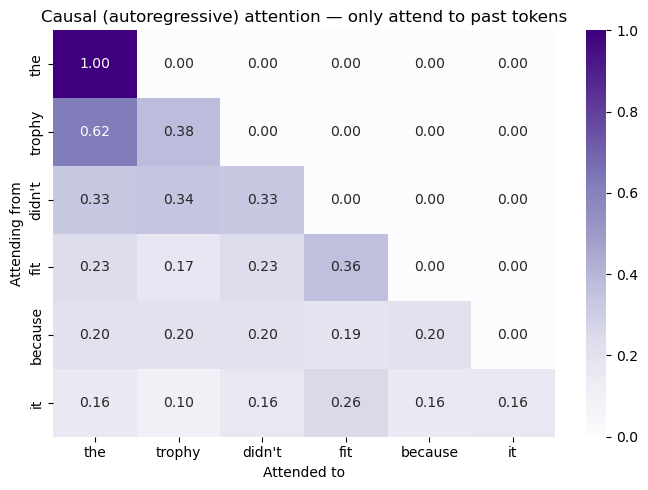

In [21]:
# Causal mask — upper triangle (future tokens) set to -inf.
# triu(..., diagonal=1) keeps everything strictly ABOVE the diagonal; those become -inf,
# the rest stay 0. Shape (6, 6).
mask = torch.triu(torch.full((6, 6), float('-inf')), diagonal=1)
print("Causal mask:")
print(mask.numpy())

# Apply to our scores and re-softmax.
# Adding -inf to "future" cells means softmax turns them into exactly 0 (e^-inf = 0),
# so each token can only attend to itself and earlier tokens — never the future.
masked_scores = scores + mask
causal_attn = F.softmax(masked_scores / (D ** 0.5), dim=-1)

# Heatmap shows a lower-triangular pattern: row i has weight only on columns <= i.
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(causal_attn.numpy(), annot=True, fmt='.2f', cmap='Purples',
            xticklabels=TOKENS, yticklabels=TOKENS, vmin=0, vmax=1, ax=ax)
ax.set_title('Causal (autoregressive) attention — only attend to past tokens')
ax.set_xlabel('Attended to')
ax.set_ylabel('Attending from')
plt.tight_layout()
plt.show()

See the lower-triangular pattern? Each row sums to 1, but the upper-triangular cells are 0. Token 3 attends to tokens 0, 1, 2, 3 — but not 4 or 5 (the future).

This single change is what makes GPT generative. The architecture is otherwise identical to BERT. Same Lego brick, different mask.

## E2 · Attention complexity

Attention computes pairwise scores between every pair of tokens. For a sequence of length N, that's O(N²) operations and O(N²) memory.

For N=512 (typical BERT max length), that's 262K pairs per layer — fine.
For N=8,192 (long-context model), that's 67M pairs per layer — expensive.
For N=128,000 (Claude / GPT-4 long context), that's 16 *billion* pairs per layer.

This is why long-context LLMs are slower and more expensive. Recent research (Flash Attention, sliding window, Mamba) tries to bring the cost down — but vanilla attention is still O(N²).

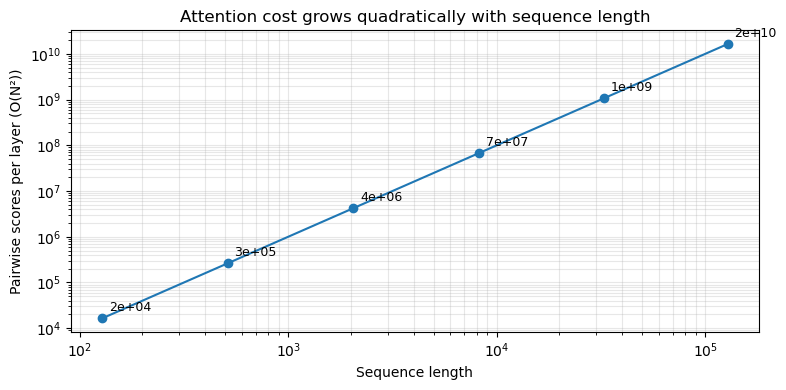

In [22]:
# Visualise attention cost growth
import math
# A range of sequence lengths from short (128) to huge long-context (128k tokens).
seq_lens = [128, 512, 2048, 8192, 32768, 128000]
# Attention compares every token with every other -> N*N pairwise scores per layer (O(N^2)).
costs = [n**2 for n in seq_lens]

# Log-log plot: a straight line confirms the quadratic (power-law) growth in cost.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(seq_lens, costs, marker='o')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Sequence length')
ax.set_ylabel('Pairwise scores per layer (O(N²))')
ax.set_title('Attention cost grows quadratically with sequence length')
ax.grid(alpha=0.3, which='both')
# Annotate each point with its pairwise-score count in scientific notation.
for n, c in zip(seq_lens, costs):
    ax.annotate(f'{c:,.0e}', (n, c), textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.tight_layout()
plt.show()

**Practical implication:** when a customer asks 'can you process this 200-page document?', the answer involves serious cost arithmetic. Long context isn't free.